---
## CELL 1: Configuration et Imports

In [ ]:
# Configuration initiale avant d'importer TensorFlow
# On desactive XLA car il cause des problemes avec certaines cartes graphiques

import os

# Ces lignes desactivent la compilation XLA qui peut faire planter le programme
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=-1'
os.environ['TF_DISABLE_MKL'] = '1'

# Imports des bibliotheques necessaires
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# Desactive aussi le JIT apres l'import pour etre sur
tf.config.optimizer.set_jit(False)

# Affiche les infos de configuration
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")
print(f"XLA/JIT: desactive")

2025-12-03 00:42:36.921034: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-03 00:42:37.104492: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.10.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
XLA/JIT: complètement désactivé


2025-12-03 00:42:41.558052: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-12-03 00:42:41.605619: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-12-03 00:42:41.607889: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


---
## CELL 2: Parametres Globaux

In [ ]:
# Ici on definit tous les parametres qu'on va utiliser dans le projet
# C'est plus facile de les modifier ici plutot que dans tout le code

# Le dossier ou se trouvent les images
DATASET_PATH = './Dataset'

# Taille des images en pixels (largeur, hauteur)
# 224x224 c'est la taille standard pour MobileNetV2
IMAGE_SIZE = (224, 224)

# Nombre d'images traitees en meme temps
# 32 c'est un bon compromis entre vitesse et memoire
BATCH_SIZE = 32

# Nombre de fois qu'on va parcourir tout le dataset
EPOCHS = 20

# Vitesse d'apprentissage du modele
# Plus c'est petit, plus le modele apprend lentement mais precisement
LEARNING_RATE = 0.001

# Affiche un resume de la configuration
print("Configuration MobileNetV2:")
print(f"   Image size: {IMAGE_SIZE}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Epochs: {EPOCHS}")
print(f"   Learning rate: {LEARNING_RATE}")

🔧 Configuration MobileNetV2:
   📐 Image size: (224, 224)
   📦 Batch size: 32
   🔄 Epochs: 20
   📈 Learning rate: 0.001


---
## CELL 3: Collecte des Images et Split des Donnees

In [ ]:
# On va parcourir tous les dossiers du dataset pour recuperer les images
# Chaque dossier correspond a une classe (une maladie de plante)

# Listes pour stocker les chemins et les noms des classes
all_files = []
all_labels = []

# On parcourt chaque dossier dans Dataset
for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)
    
    # On verifie que c'est bien un dossier
    if os.path.isdir(class_path):
        # On parcourt chaque image dans le dossier
        for img_file in os.listdir(class_path):
            # On garde seulement les fichiers images
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                all_files.append(os.path.join(class_path, img_file))
                all_labels.append(class_name)

print(f"Total images trouvees: {len(all_files)}")


# Premier split: on separe 70% pour train et 30% pour le reste
train_files, temp_files, train_labels, temp_labels = train_test_split(
    all_files,
    all_labels,
    test_size=0.30,        
    random_state=42,       
    stratify=all_labels    
)


val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

# On cree des DataFrames pandas pour organiser les donnees
train_df = pd.DataFrame({'filename': train_files, 'class': train_labels})
val_df = pd.DataFrame({'filename': val_files, 'class': val_labels})
test_df = pd.DataFrame({'filename': test_files, 'class': test_labels})

print(f"\nTraining: {len(train_df)} images (70%)")
print(f"Validation: {len(val_df)} images (15%)")
print(f"Test: {len(test_df)} images (15%)")

📊 Total images trouvées: 35725

✅ Training: 25007 images (70%)
✅ Validation: 5359 images (15%)
✅ Test: 5359 images (15%)


---
## CELL 4: Augmentation des Donnees et Generateurs

In [ ]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator
import io
import sys

# Configuration de l'augmentation pour l'entrainement
# On applique des transformations aleatoires aux images
train_datagen = ImageDataGenerator(
    rescale=1./255,            # Normalise les pixels entre 0 et 1
    rotation_range=40,         # Rotation aleatoire jusqu'a 40 degres
    width_shift_range=0.2,     # Decalage horizontal jusqu'a 20%
    height_shift_range=0.2,    # Decalage vertical jusqu'a 20%
    shear_range=0.2,           # Deformation de l'image
    zoom_range=[0.8, 1.2],     # Zoom entre 80% et 120%
    horizontal_flip=True,      # Retournement horizontal
    vertical_flip=True,        # Retournement vertical
    brightness_range=[0.8, 1.2],  # Variation de luminosite
    fill_mode='nearest'        # Comment remplir les pixels vides
)

# Pour la validation et le test, on fait juste la normalisation
# Pas d'augmentation car on veut evaluer sur les vraies images
valid_test_datagen = ImageDataGenerator(rescale=1./255)

# On cache les messages de Keras qui sont trop verbeux
old_stdout = sys.stdout
sys.stdout = io.StringIO()

# Creation des generateurs qui vont fournir les images par batch
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='class',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42
)

validation_generator = valid_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filename',
    y_col='class',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=42
)

test_generator = valid_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filename',
    y_col='class',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Important: pas de melange pour le test
)

# On remet l'affichage normal
sys.stdout = old_stdout

# On recupere les infos sur les classes
num_classes = len(train_generator.class_indices)
class_names = list(train_generator.class_indices.keys())

print(f"Nombre de classes: {num_classes}")
print(f"Exemples de classes: {class_names[:5]}...")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"Test samples: {test_generator.samples}")

✅ Classes (23): ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot']...
📊 Training samples: 25007
📊 Validation samples: 5359
📊 Test samples: 5359


---
## CELL 5: Visualisation des Images Augmentees

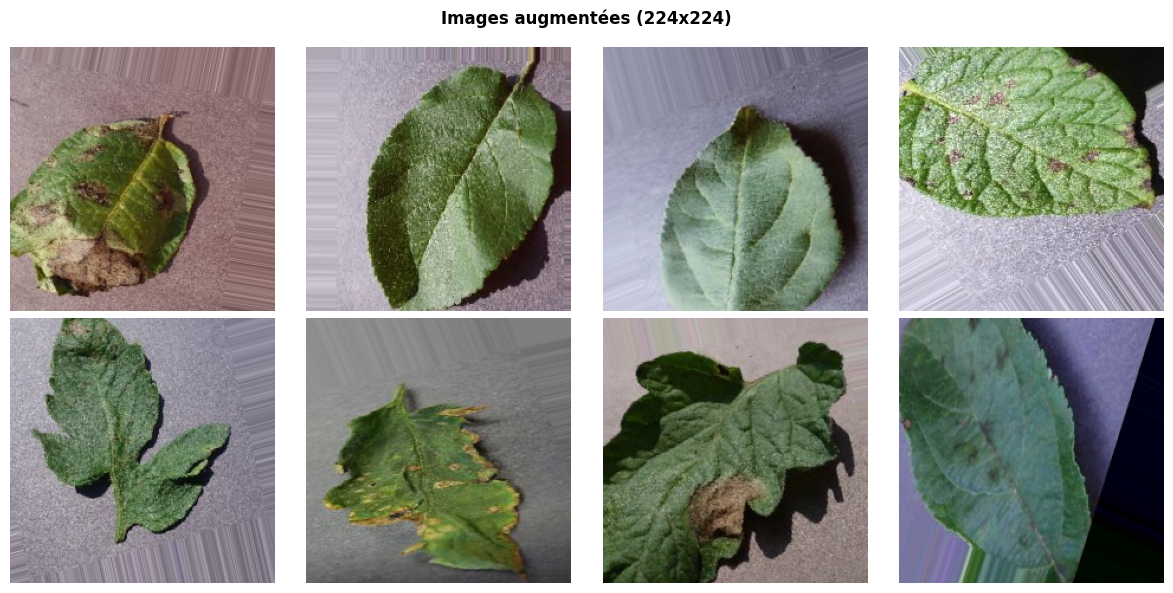

In [ ]:
# On affiche quelques images pour voir a quoi ressemble l'augmentation
# Ca permet de verifier que les transformations sont correctes

# On recupere un batch d'images
images, labels = next(train_generator)

# On cree une grille de 2x4 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i])
    ax.axis('off')

plt.suptitle(f'Images augmentees (224x224)')
plt.tight_layout()
plt.show()

---
## CELL 6: Construction du Modele MobileNetV2

In [ ]:
# On utilise le Transfer Learning avec MobileNetV2
# C'est un modele deja entraine sur ImageNet (des millions d'images)
# On va reutiliser ses connaissances pour notre probleme

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input



# On charge MobileNetV2 sans sa couche de classification finale car on va ajouter notre propre classification pour nos classes
base_model = MobileNetV2(
    weights='imagenet',      # On prend les poids pre-entraines
    include_top=False,       # On enleve la classification d'origine
    input_shape=(224, 224, 3)
)

# On gele le modele de base pour ne pas modifier ses poids au debut, ca permet d'entrainer seulement notre nouvelle classification
base_model.trainable = False

print(f"MobileNetV2 charge ({len(base_model.layers)} couches)")
print(f"Couches gelees: {len(base_model.layers)}")

# On construit le modele complet en ajoutant nos couches
inputs = Input(shape=(224, 224, 3))

# L'image passe d'abord par MobileNetV2 pour extraire les features
x = base_model(inputs, training=False)

# GlobalAveragePooling reduit les dimensions en faisant une moyenne
x = GlobalAveragePooling2D()(x)

# Une couche Dense pour apprendre des combinaisons de features
x = Dense(256, activation='relu')(x)

# Dropout pour eviter l'overfitting (on desactive 40% des neurones aleatoirement)
x = Dropout(0.4)(x)

# La couche finale avec une sortie par classe
outputs = Dense(num_classes, activation='softmax')(x)

# On assemble le tout
model = Model(inputs, outputs)

# On affiche les statistiques du modele
trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
non_trainable_params = sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights])

print(f"\nSTATISTIQUES DU MODELE:")
print(f"   Parametres entrainables: {trainable_params:,}")
print(f"   Parametres geles: {non_trainable_params:,}")
print(f"   Total: {trainable_params + non_trainable_params:,}")

📥 Chargement de MobileNetV2 pré-entraîné sur ImageNet...


2025-12-03 00:42:56.795955: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-03 00:42:56.797737: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-12-03 00:42:56.803200: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-12-03 00:42:56.806954: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:980] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node,

✅ MobileNetV2 chargé (154 couches)
🔒 Couches gelées: 154

📊 STATISTIQUES DU MODÈLE:
   ├─ Paramètres entraînables: 333,847
   ├─ Paramètres gelés: 2,257,984
   └─ Total: 2,591,831

📊 STATISTIQUES DU MODÈLE:
   ├─ Paramètres entraînables: 333,847
   ├─ Paramètres gelés: 2,257,984
   └─ Total: 2,591,831


Le modele a 4 couche + les couche de mobileNetV2 154 + 4 : 158 couche 
couche 1: Pooling
couche 2 : Apprend les combinaison transforme vect de 1280 en 256 d'ou 333k parametre 
couche 3 : desactive aletoirement des neurones 
couche 4 : sortie en nombre de classe 23  


## CELL 7: Compilation du Modele

In [ ]:
# La compilation configure comment le modele va apprendre
# On doit definir l'optimiseur, la fonction de perte et les metriques

from tensorflow.keras.optimizers import Adam

model.compile(
    # Adam est un optimiseur qui ajuste automatiquement le learning rate
    optimizer=Adam(learning_rate=LEARNING_RATE),
    
    # Categorical crossentropy car on a plusieurs classes
    loss='categorical_crossentropy',
    
    # L'accuracy nous dit le pourcentage de bonnes predictions
    metrics=['accuracy']
)

print("Modele compile avec:")
print(f"   Optimizer: Adam (lr={LEARNING_RATE})")
print(f"   Loss: categorical_crossentropy")
print(f"   Metrics: accuracy")

# Affiche un resume de l'architecture
model.summary()

✅ Modèle compilé avec:
   ├─ Optimizer: Adam (lr=0.001)
   ├─ Loss: categorical_crossentropy
   └─ Metrics: accuracy
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 256)               327936    
                                                                 
 dropout (Dropout)           (None, 256)               0         
          

---
## CELL 8: Test de Timing (1 Epoch)

In [ ]:
# On fait un test avec 1 seul epoch pour estimer le temps total
# Ca permet de savoir combien de temps va durer l'entrainement complet

import time

# On detecte si on utilise le GPU ou le CPU
device = "GPU" if tf.config.list_physical_devices('GPU') else "CPU"

print("="*60)
print("TEST DE TIMING - 1 EPOCH")
print("="*60)

# Calcul du nombre de batches par epoch
steps_per_epoch = train_generator.samples // BATCH_SIZE
val_steps = validation_generator.samples // BATCH_SIZE

print(f"Configuration:")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Steps per epoch: {steps_per_epoch}")
print(f"   Validation steps: {val_steps}")
print(f"   Device: {device}")
print("="*60)

# On lance le chrono
start_time = time.time()

# Entrainement sur 1 epoch
test_history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=validation_generator,
    validation_steps=val_steps,
    epochs=1,
    verbose=1
)

# Temps ecoule
epoch_time = time.time() - start_time

# Estimation du temps total
estimated_total = epoch_time * EPOCHS

print("\n" + "="*60)
print("RESULTATS DU TEST")
print("="*60)
print(f"Temps pour 1 epoch: {epoch_time:.1f} secondes ({epoch_time/60:.2f} minutes)")
print(f"\nESTIMATION POUR {EPOCHS} EPOCHS:")
print(f"   Temps estime: {estimated_total/60:.1f} minutes")
print(f"   Soit environ: {estimated_total/3600:.2f} heures")
print("="*60)
print(f"\nAccuracy apres 1 epoch: {test_history.history['accuracy'][0]*100:.2f}%")
print(f"Val Accuracy apres 1 epoch: {test_history.history['val_accuracy'][0]*100:.2f}%")

⏱️ TEST DE TIMING - 1 EPOCH
📊 Configuration:
   ├─ Batch size: 32
   ├─ Steps per epoch: 781
   ├─ Validation steps: 167
   └─ Device: GPU


2025-12-03 00:43:11.382186: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8907
2025-12-03 00:43:11.446336: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-12-03 00:43:11.446551: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-12-03 00:43:11.446563: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2025-12-03 00:43:11.446961: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-12-03 00:43:11.447072: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.


  2/781 [..............................] - ETA: 40s - loss: 3.8071 - accuracy: 0.0469  

2025-12-03 00:43:11.672340: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


781/781 [==============================] - 251s 318ms/step - loss: 0.8679 - accuracy: 0.7284 - val_loss: 0.4728 - val_accuracy: 0.8430

📊 RÉSULTATS DU TEST
⏱️ Temps pour 1 epoch: 251.3 secondes (4.19 minutes)

📈 ESTIMATION POUR 20 EPOCHS:
   ├─ Temps estimé: 83.8 minutes
   └─ Soit environ: 1.40 heures

✅ Accuracy après 1 epoch: 72.84%
✅ Val Accuracy après 1 epoch: 84.30%
781/781 [==============================] - 251s 318ms/step - loss: 0.8679 - accuracy: 0.7284 - val_loss: 0.4728 - val_accuracy: 0.8430

📊 RÉSULTATS DU TEST
⏱️ Temps pour 1 epoch: 251.3 secondes (4.19 minutes)

📈 ESTIMATION POUR 20 EPOCHS:
   ├─ Temps estimé: 83.8 minutes
   └─ Soit environ: 1.40 heures

✅ Accuracy après 1 epoch: 72.84%
✅ Val Accuracy après 1 epoch: 84.30%



## CELL 9: Configuration des Callbacks

In [ ]:
# Les callbacks sont des fonctions qui s'executent pendant l'entrainement
# Ils permettent d'automatiser certaines actions

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    # EarlyStopping arrete l'entrainement si le modele ne s'ameliore plus
    # Patience=7 signifie qu'on attend 7 epochs sans amelioration avant d'arreter
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,  # On garde les meilleurs poids
        verbose=1
    ),
    
    # ReduceLROnPlateau reduit le learning rate quand on stagne
    # Ca aide a sortir des minimums locaux
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,      # On multiplie le LR par 0.2
        patience=3,      # Apres 3 epochs sans amelioration
        min_lr=1e-7,     # On ne descend pas en dessous de cette valeur
        verbose=1
    ),
    
    # ModelCheckpoint sauvegarde le meilleur modele
    ModelCheckpoint(
        'best_mobilenet_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks configures:")
print("   EarlyStopping (patience=7)")
print("   ReduceLROnPlateau (patience=3)")
print("   ModelCheckpoint (best_mobilenet_model.keras)")

✅ Callbacks configurés:
   ├─ EarlyStopping (patience=7)
   ├─ ReduceLROnPlateau (patience=3)
   └─ ModelCheckpoint (best_mobilenet_model.keras)


ModelCheckpoint sauvgarde le meilleur model avec le metric de val_accuracy l'accuracy sur les donne de validation pendant l'entrainement a l'epoche ou le modele a atteint la meilleur val_accuracy c'est celui ou sera sauvgarder 

In [ ]:
# C'est ici que l'entrainement principal se passe
# Le modele va apprendre a reconnaitre les maladies des plantes

import time

# On verifie quel device est utilise
device = "GPU" if tf.config.list_physical_devices('GPU') else "CPU"

print("="*60)
print("ENTRAINEMENT AVEC BASE GELEE")
print("="*60)
print(f"Configuration:")
print(f"   Epochs: {EPOCHS}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Device: {device}")
print(f"   Base model: GELE (on entraine seulement la classification)")
print("="*60)

start_time = time.time()

# Lancement de l'entrainement
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

total_time = time.time() - start_time
epochs_trained = len(history.history['loss'])

print("\n" + "="*60)
print("ENTRAINEMENT TERMINE!")
print("="*60)
print(f"Temps total: {total_time/60:.1f} minutes")
print(f"Temps moyen par epoch: {total_time/epochs_trained:.1f} secondes")
print(f"Epochs effectues: {epochs_trained}")

🚀 PHASE 1: ENTRAÎNEMENT AVEC BASE GELÉE
📊 Configuration:
   ├─ Epochs: 20
   ├─ Batch size: 32
   ├─ Device: GPU
   └─ Base model: GELÉ
Epoch 1/20
Epoch 1/20
781/781 [==============================] - ETA: 0s - loss: 0.5253 - accuracy: 0.8232
Epoch 1: val_accuracy improved from -inf to 0.87219, saving model to best_mobilenet_model.keras

Epoch 1: val_accuracy improved from -inf to 0.87219, saving model to best_mobilenet_model.keras
781/781 [==============================] - 244s 313ms/step - loss: 0.5253 - accuracy: 0.8232 - val_loss: 0.3844 - val_accuracy: 0.8722 - lr: 0.0010
Epoch 2/20
Epoch 2/20
781/781 [==============================] - ETA: 0s - loss: 0.4710 - accuracy: 0.8425
Epoch 2: val_accuracy improved from 0.87219 to 0.89652, saving model to best_mobilenet_model.keras

Epoch 2: val_accuracy improved from 0.87219 to 0.89652, saving model to best_mobilenet_model.keras
781/781 [==============================] - 235s 301ms/step - loss: 0.4710 - accuracy: 0.8425 - val_loss: 0.321

---
## CELL 10: Courbes d'Apprentissage

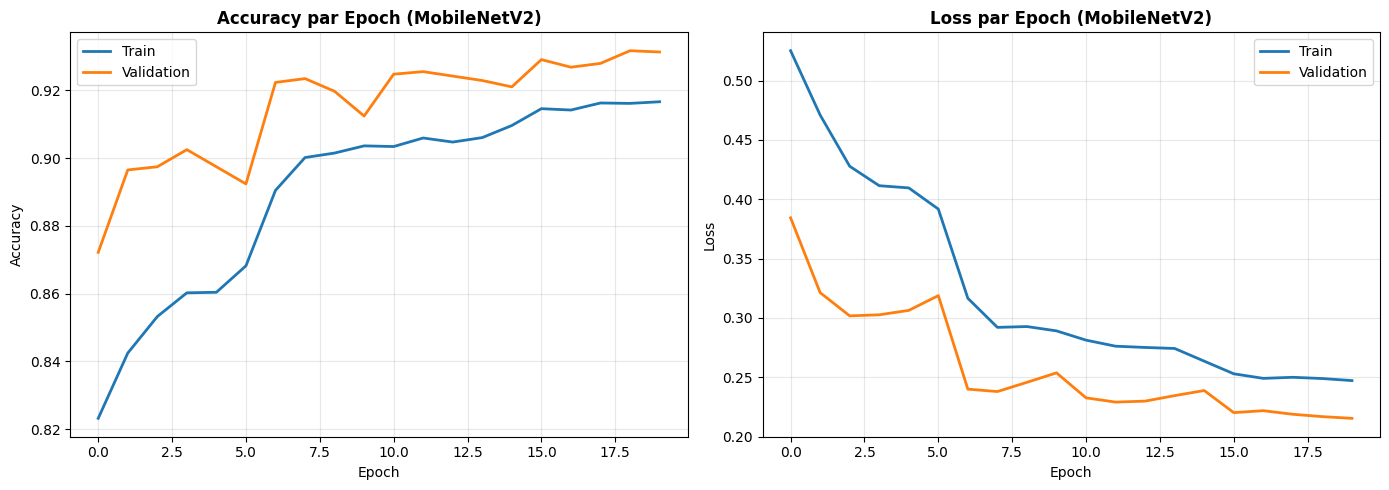


🏆 Meilleure validation accuracy: 93.17% (Epoch 19)


In [ ]:
# On trace les courbes pour voir comment le modele a appris
# C'est utile pour detecter l'overfitting ou d'autres problemes

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe de l'accuracy
axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Accuracy par Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Courbe de la loss
axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Loss par Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# On affiche la meilleure performance
best_val_acc = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_acc) + 1

print(f"\nMeilleure validation accuracy: {best_val_acc*100:.2f}% (Epoch {best_epoch})")

---
## CELL 11: Evaluation sur le Test Set

In [ ]:
# Maintenant on evalue le modele sur les images de test
# Ces images n'ont jamais ete vues pendant l'entrainement

test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"\n{'='*50}")
print(f"RESULTATS SUR LE TEST SET")
print(f"{'='*50}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print(f"{'='*50}")

# On verifie si on a atteint l'objectif
if test_accuracy >= 0.85:
    print(f"\nOBJECTIF ATTEINT! Accuracy >= 85%")
else:
    print(f"\nAccuracy < 85%. Pour ameliorer:")
    print(f"   - Utiliser le fine-tuning (voir mobilenet_finetuning.ipynb)")
    print(f"   - Augmenter le nombre d'epochs")

168/168 [==============================] - 9s 53ms/step - loss: 0.2270 - accuracy: 0.9241

🎯 RÉSULTATS SUR LE TEST SET (MobileNetV2)
📈 Test Accuracy: 92.41%
📉 Test Loss: 0.2270

✅ OBJECTIF ATTEINT! Accuracy ≥ 85%
168/168 [==============================] - 9s 53ms/step - loss: 0.2270 - accuracy: 0.9241

🎯 RÉSULTATS SUR LE TEST SET (MobileNetV2)
📈 Test Accuracy: 92.41%
📉 Test Loss: 0.2270

✅ OBJECTIF ATTEINT! Accuracy ≥ 85%


---
## CELL 12: Matrice de Confusion et Rapport de Classification

In [ ]:
# La matrice de confusion montre ou le modele se trompe
# Ca permet de voir quelles classes sont confondues

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# On remet le generateur au debut
test_generator.reset()

# On genere les predictions pour toutes les images de test
predictions = model.predict(test_generator, steps=len(test_generator), verbose=1)

# On convertit les probabilites en classes
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Rapport de classification avec precision, recall et f1-score
print("\nRAPPORT DE CLASSIFICATION")
print("="*60)
print(classification_report(y_true, y_pred, target_names=class_names))

# On calcule la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# On l'affiche avec une heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Matrice de Confusion', fontweight='bold', fontsize=14)
plt.xlabel('Prediction')
plt.ylabel('Vraie Classe')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'seaborn'

---
## CELL 13: Sauvegarde du Modele

In [ ]:
# On sauvegarde le modele et toutes les infos
# Pour pouvoir le reutiliser plus tard sans re-entrainer

import json

# On sauvegarde en deux formats pour etre compatible
# .keras est le nouveau format, .h5 est l'ancien mais toujours utilise
model.save('mobilenet_plant_disease.keras')
model.save('mobilenet_plant_disease.h5')

# On garde aussi les noms des classes
# Sinon on saura pas quelle classe correspond a quel index
with open('mobilenet_class_names.json', 'w') as f:
    json.dump(class_names, f)

# Et la config complete pour se rappeler comment on a entraine
config = {
    'model_name': 'MobileNetV2',
    'image_size': IMAGE_SIZE,
    'batch_size': BATCH_SIZE,
    'num_classes': num_classes,
    'mixed_precision': True,
    'test_accuracy': float(test_accuracy),
    'epochs_trained': len(history.history['loss'])
}

with open('mobilenet_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Modele sauvegarde !")
print("Fichiers crees:")
print("   - mobilenet_plant_disease.keras")
print("   - mobilenet_plant_disease.h5")
print("   - best_mobilenet_model.keras (meilleur checkpoint)")
print("   - mobilenet_class_names.json")
print("   - mobilenet_config.json")

---
## CELL 14: Exemples de Predictions

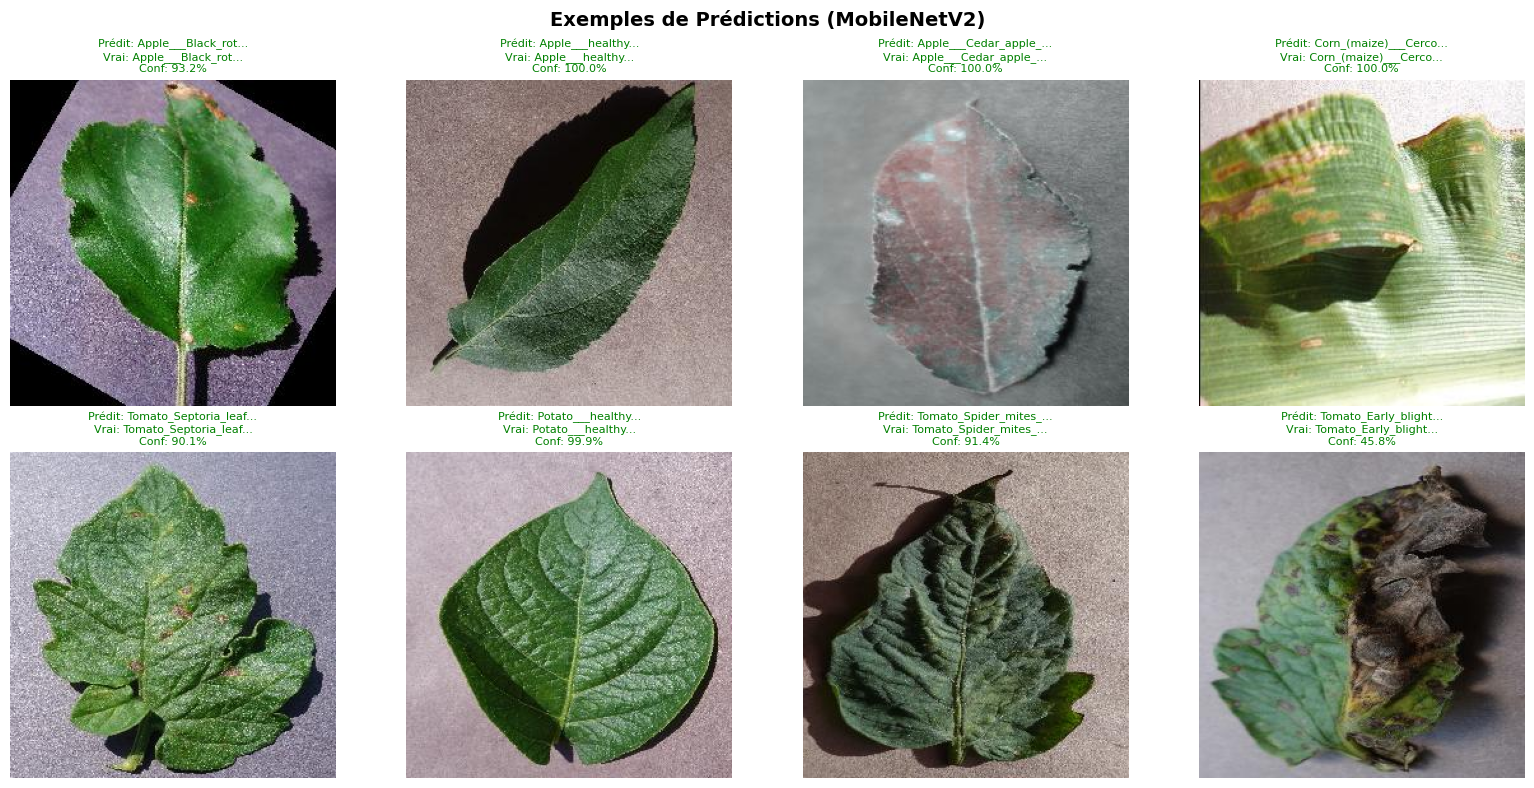


📊 RÉSUMÉ FINAL - MOBILENETV2 TRANSFER LEARNING

🔧 CONFIGURATION:
   ├─ Modèle: MobileNetV2 (ImageNet)
   ├─ Image size: (224, 224)
   ├─ Mixed Precision: FP16
   └─ Base model: Gelé

📈 PERFORMANCES:
   ├─ Test Accuracy: 92.41%
   ├─ Best Val Accuracy: 93.17%
   └─ Epochs: 20


In [ ]:
# Fonction pour predire sur une seule image
# Utile pour tester le modele sur de nouvelles images

def predict_disease(image_path, model, class_names):
    """
    Prend une image et retourne la maladie predite avec la confiance.
    """
    # On charge l'image a la bonne taille
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=IMAGE_SIZE)
    
    # On la convertit en array numpy
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    
    # Normalisation entre 0 et 1
    img_array = img_array / 255.0
    
    # On ajoute une dimension batch (le modele attend [batch, height, width, channels])
    img_array = np.expand_dims(img_array, axis=0)
    
    # Prediction
    predictions = model.predict(img_array, verbose=0)
    predicted_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_index]
    confidence = np.max(predictions[0]) * 100
    
    return predicted_class, confidence


# On affiche quelques exemples de predictions
# Vert = bonne prediction, Rouge = erreur

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, ax in enumerate(axes.flatten()):
    # On prend une image au hasard
    idx = np.random.randint(0, len(test_df))
    img_path = test_df.iloc[idx]['filename']
    true_class = test_df.iloc[idx]['class']
    
    # On fait la prediction
    predicted_class, confidence = predict_disease(img_path, model, class_names)
    
    # On affiche
    img = Image.open(img_path)
    ax.imshow(img)
    
    # Couleur selon si c'est correct ou pas
    color = 'green' if predicted_class == true_class else 'red'
    ax.set_title(f"Predit: {predicted_class[:20]}...\nVrai: {true_class[:20]}...\nConf: {confidence:.1f}%", 
                 fontsize=8, color=color)
    ax.axis('off')

plt.suptitle('Exemples de Predictions (MobileNetV2)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('mobilenet_predictions.png', dpi=150)
plt.show()


# Resume final de l'entrainement
print("\n" + "="*60)
print("RESUME FINAL - MOBILENETV2 TRANSFER LEARNING")
print("="*60)
print(f"\nCONFIGURATION:")
print(f"   - Modele: MobileNetV2 (ImageNet)")
print(f"   - Taille image: {IMAGE_SIZE}")
print(f"   - Mixed Precision: FP16")
print(f"   - Base model: Gele (non entrainable)")

print(f"\nPERFORMANCES:")
print(f"   - Test Accuracy: {test_accuracy*100:.2f}%")
print(f"   - Best Val Accuracy: {best_val_acc*100:.2f}%")
print(f"   - Nombre d'epochs: {len(history.history['loss'])}")
print("="*60)